# Estudio comparativo del algoritmo Epsilon-Greedy


## Introducción



El algoritmo **Epsilon-Greedy** es uno de los métodos más fundamentales y utilizados para abordar el problema del dilema exploración-explotación en el aprendizaje por refuerzo.

La idea básica es equilibrar dos objetivos competitivos:
1.  **Explotación**: Elegir la acción que, según nuestro conocimiento actual, tiene la mayor recompensa estimada ($Q_t(a)$).
2.  **Exploración**: Elegir una acción diferente (potencialmente al azar) para recopilar más información sobre el entorno y refinar nuestras estimaciones.

El algoritmo funciona con un parámetro $\epsilon$ (epsilon), donde $0 \le \epsilon \le 1$. En cada paso $t$:
*   Con probabilidad $1 - \epsilon$, el agente selecciona la acción *greedy* (avariciosa): $A_t = \arg\max_a Q_t(a)$.
*   Con probabilidad $\epsilon$, el agente selecciona una acción aleatoria de entre todas las $k$ acciones posibles con probabilidad uniforme.

Matemáticamente, la probabilidad de seleccionar una acción $a$ es:
$$ 
\pi_t(a) = \begin{cases} 
(1 - \epsilon) + \frac{\epsilon}{k} & \text{si } a = A^*_t \text{ (acción greedy)} \\
\frac{\epsilon}{k} & \text{si } a \neq A^*_t 
\end{cases}
$$

En este estudio analizaremos el comportamiento de este algoritmo variando el valor de $\epsilon$. Un $\epsilon$ muy bajo favorece la explotación pero corre el riesgo de no encontrar la acción óptima rápidamente. Un $\epsilon$ alto asegura mucha exploración pero impide maximizar la recompensa a largo plazo.



En este estudio se analizará el algoritmo Epsilon-Greedy utilizando tres tipos de bandidos diferentes: Normal, Binomial y Bernoulli. Se establecerán parámetros comunes, se crearán los bandidos y se evaluará el rendimiento en términos de recompensa promedio, arrepentimiento (regret) y selección óptima.


## Preparación del entorno


In [51]:
# Librerías necesarias para el setup
import sys, os


En función de si el notebook se va a ejecutar en local o en Google Colab, se debe ejecutar una de las siguientes subsecciones.


### Setup para la ejecución en Colab


In [52]:
# Clonar el repositorio si es necesario


In [53]:
# Añadir directorios al path si es necesario


### Setup para la ejecución en local


In [54]:
# Añadir el directorio src al path para importar los módulos
src_path = os.path.abspath(os.path.join(os.getcwd(), 'src'))
if src_path not in sys.path:
    sys.path.append(src_path)
    
print(sys.path)

['c:\\Users\\fluca\\anaconda3\\python313.zip', 'c:\\Users\\fluca\\anaconda3\\DLLs', 'c:\\Users\\fluca\\anaconda3\\Lib', 'c:\\Users\\fluca\\anaconda3', '', 'c:\\Users\\fluca\\anaconda3\\Lib\\site-packages', 'c:\\Users\\fluca\\anaconda3\\Lib\\site-packages\\win32', 'c:\\Users\\fluca\\anaconda3\\Lib\\site-packages\\win32\\lib', 'c:\\Users\\fluca\\anaconda3\\Lib\\site-packages\\Pythonwin', 'c:\\Users\\fluca\\OneDrive\\Documentos\\0 Master IA\\9_ExtensionML\\EML_RL_LucasOrtiz-manV2\\k_brazos\\src']


### Importación de librerías y módulos


In [55]:
import numpy as np

from algorithms import EpsilonGreedy
from arms import Bandit, ArmNormal, ArmBinomial, ArmBernoulli
from plotting import plot_average_rewards, plot_optimal_selections, plot_regret, plot_arm_statistics
from run_experiment import run_experiment


## Parámetros generales


A continuación, definimos la configuración experimental compartida por todas las pruebas. Se ha fijado una semilla aleatoria (`SEED`) para asegurar que los resultados sean reproducibles. Los entornos constan de bandidos con $k=6$ brazos, una cantidad seleccionada para facilitar la interpretación visual de las estadísticas individuales de cada acción. El horizonte temporal de cada simulación se ha limitado a 300 pasos de tiempo, un intervalo suficiente para observar la convergencia de los algoritmos evaluados. Para obtener estimaciones robustas, cada experimento se promedia sobre 500 ejecuciones independientes.

Adicionalmente, es importante destacar que la implementación de los agentes incorpora una etapa preliminar de **inicialización**. En esta fase, cada algoritmo acciona cada una de las palancas disponibles exactamente una vez antes de iniciar su estrategia de aprendizaje propiamente dicha. Se ha constatado experimentalmente que esta heurística de exploración inicial acelera y estabiliza significativamente el proceso de convergencia.


In [56]:
SEMILLA = 1024

k = 6  # Número de brazos
steps = 300  # Número de pasos
runs = 500  # Número de ejecuciones


## Creación de los bandidos


En este apartado configuramos los tres bandidos necesarios para la comparativa. El primero de ellos se basa en brazos con distribución normal, manteniendo los valores predeterminados para la desviación estándar (entre 1 y 3). Sin embargo, hemos ajustado las medias a un rango más estrecho, entre 5 y 10. El objetivo de reducir esta dispersión entre medias es dificultar la identificación del brazo óptimo; al ralentizar la convergencia, podremos apreciar mejor las sutilezas y el rendimiento diferencial de cada algoritmo.

### Bandido Normal


Medias entre 5 y 10 para dificultar la distinción.


In [57]:
# Creación del bandit normal
np.random.seed(SEMILLA)
bandit_normal = Bandit(arms=ArmNormal.generate_arms(k, mu_min=5, mu_max=10))
print(bandit_normal)

optimal_arm_normal = bandit_normal.optimal_arm
print(f"Optimal arm: {optimal_arm_normal + 1} with expected reward={bandit_normal.get_expected_value(optimal_arm_normal)}")


Bandit with 6 arms: ArmNormal(mu=7.59, sigma=1.27), ArmNormal(mu=8.24, sigma=1.01), ArmNormal(mu=9.98, sigma=1.3), ArmNormal(mu=8.0, sigma=2.4), ArmNormal(mu=8.29, sigma=2.19), ArmNormal(mu=8.77, sigma=2.8)
Optimal arm: 3 with expected reward=9.98


Como podemos observar en la salida de la celda anterior, el **Brazo 3** resulta ser el óptimo con una recompensa esperada de **9.98**. Las medias de los otros brazos oscilan entre 7.59 y 8.77, lo que presenta un desafío moderado para diferenciar el mejor brazo debido a la varianza inherente ($\sigma$ entre 1.01 y 2.8).


### Bandido Binomial


Probabilidad entre 0.1 y 0.9, n entre 5 y 15.


In [58]:
# Creación del bandit binomial
np.random.seed(SEMILLA)
bandit_binomial = Bandit(arms=ArmBinomial.generate_arms(k, n_min=5, n_max=15))
print(bandit_binomial)

optimal_arm_binomial = bandit_binomial.optimal_arm
print(f"Optimal arm: {optimal_arm_binomial + 1} with expected reward={bandit_binomial.get_expected_value(optimal_arm_binomial)}")


Bandit with 6 arms: ArmBinomial(n=6, p=0.58), ArmBinomial(n=6, p=0.7), ArmBinomial(n=10, p=0.22), ArmBinomial(n=14, p=0.21), ArmBinomial(n=6, p=0.1), ArmBinomial(n=5, p=0.66)
Optimal arm: 2 with expected reward=4.199999999999999


En el caso del bandido Binomial, el **Brazo 2** es el óptimo con una recompensa esperada aproximada de **4.2**. Cabe destacar que este brazo tiene $n=6$ y $p=0.7$, lo cual supera a otras combinaciones como el Brazo 3 ($n=10, p=0.22$) a pesar de tener un $n$ menor, demostrando la importancia de la probabilidad de éxito.


### Bandido Bernoulli


In [59]:
# Creación del bandit bernoulli
np.random.seed(SEMILLA)
bandit_bernoulli = Bandit(arms=ArmBernoulli.generate_arms(k))
print(bandit_bernoulli)

optimal_arm_bernoulli = bandit_bernoulli.optimal_arm
print(f"Optimal arm: {optimal_arm_bernoulli + 1} with expected reward={bandit_bernoulli.get_expected_value(optimal_arm_bernoulli)}")


Bandit with 6 arms: ArmBernoulli(p=0.62), ArmBernoulli(p=0.9), ArmBernoulli(p=0.63), ArmBernoulli(p=0.58), ArmBernoulli(p=0.52), ArmBernoulli(p=0.7)
Optimal arm: 2 with expected reward=0.9


Para el bandido Bernoulli, el **Brazo 2** se destaca claramente como la opción óptima con una probabilidad de éxito $p=0.9$. Dado que el siguiente mejor brazo tiene $p=0.7$, existe una separación clara ('gap') de 0.2, lo que debería facilitar teóricamente la convergencia del algoritmo hacia la acción óptima.


## Análisis de Epsilon-Greedy


Probaremos tres configuraciones de $\epsilon$: $0$ (Greedy puro), $0.01$ (Baja exploración) y $0.1$ (Exploración moderada).

La metodología experimental aplicada para evaluar estas configuraciones se detalla a continuación:

1.  **Variación del Parámetro $\epsilon$**: Se comparan escenarios representativos del compromiso exploración-explotación:
    *   **$\epsilon = 0$ (Greedy puro)**: El agente nunca explora, limitándose a explotar la acción con mayor valor estimado inicial o descubierto por azar. Sirve como línea base de explotación pura.
    *   **$\epsilon = 0.01$ (Baja exploración)**: Introduce una pequeña probabilidad de error intencional para explorar, permitiendo refinar las estimaciones a largo plazo con un costo mínimo en recompensas inmediatas.
    *   **$\epsilon = 0.1$ (Exploración moderada)**: Aumenta significativamente la frecuencia de exploración. Se espera que encuentre la acción óptima más rápidamente, aunque su rendimiento asintótico podría ser menor debido a la exploración continua de acciones subóptimas.

2.  **Métricas de Evaluación**: El desempeño se medirá utilizando tres indicadores clave:
    *   **Recompensa Promedio**: Evolución de la ganancia media paso a paso. Útil para observar la velocidad de aprendizaje y la estabilidad.
    *   **Porcentaje de Selección Óptima**: Proporción de veces que el agente elige el brazo con la mayor media real. Es la métrica más directa de la "inteligencia" del agente.
    *   **Arrepentimiento Acumulado e Instantáneo**: Diferencia entre la recompensa obtenida y la máxima posible. El arrepentimiento logarítmico es deseable y caracteriza a los buenos algoritmos.

3.  **Robustez Experimental**: Todas las curvas y métricas presentadas son el promedio de **500 ejecuciones independientes** (runs). Esto suaviza la variabilidad estocástica inherente a los procesos de bandidos y garantiza que las conclusiones sean estadísticamente significativas.


In [60]:
algorithms_epsilon = [EpsilonGreedy(k=k, epsilon=0.0), EpsilonGreedy(k=k, epsilon=0.01), EpsilonGreedy(k=k, epsilon=0.1)]


### Distribución Normal



In [61]:
np.random.seed(SEMILLA)
rewards_EN, optimal_selections_EN, cumulative_regret_per_algo_EN, rewards_per_arm_per_algo_EN = run_experiment(bandit_normal, algorithms_epsilon, steps, runs)


100%|██████████| 500/500 [00:07<00:00, 68.98it/s]


### Análisis Detallado de Recompensa Promedio (Normal)
La evolución temporal de la recompensa promedio ilustra la tensión fundamental del aprendizaje por refuerzo: el compromiso entre velocidad de convergencia y estabilidad asintótica.

*   **Estrategia $\epsilon=0.1$ (Exploración Moderada)**:
    *   **Fase Transitoria**: Exhibe la tasa de aprendizaje inicial más rápida. La exploración frecuente permite descubrir el brazo óptimo prematuramente.
    *   **Comportamiento Asintótico**: Sin embargo, su desempeño se ve acotado superiormente. Debido a que el agente está forzado a elegir una acción aleatoria el 10% de las veces, su recompensa promedio nunca puede converger al valor óptimo teórico ($q_*$), estabilizándose en un valor subóptimo (aproximadamente $0.9 \cdot q_* + 0.1 \cdot 	ext{promedio del resto}$).

*   **Estrategia $\epsilon=0.01$ (Exploración Conservadora)**:
    *   **Fase Transitoria**: El aprendizaje es más gradual. La menor frecuencia de exploración retrasa el descubrimiento inicial de la mejor acción.
    *   **Comportamiento Asintótico**: A largo plazo, esta estrategia domina. Al reducir el ruido de exploración, la política se aproxima más a la estrategia puramente codiciosa sobre el brazo óptimo, logrando una recompensa promedio superior y más estable.

*   **Estrategia $\epsilon=0$ (Greedy Puro)**:
    *   Se observa una alta dependencia de las condiciones iniciales. Al carecer de mecanismos para corregir estimaciones tempranas erróneas, el agente es propenso a converger prematuramente a ópimos locales, resultando en un desempeño global inferior y errático.

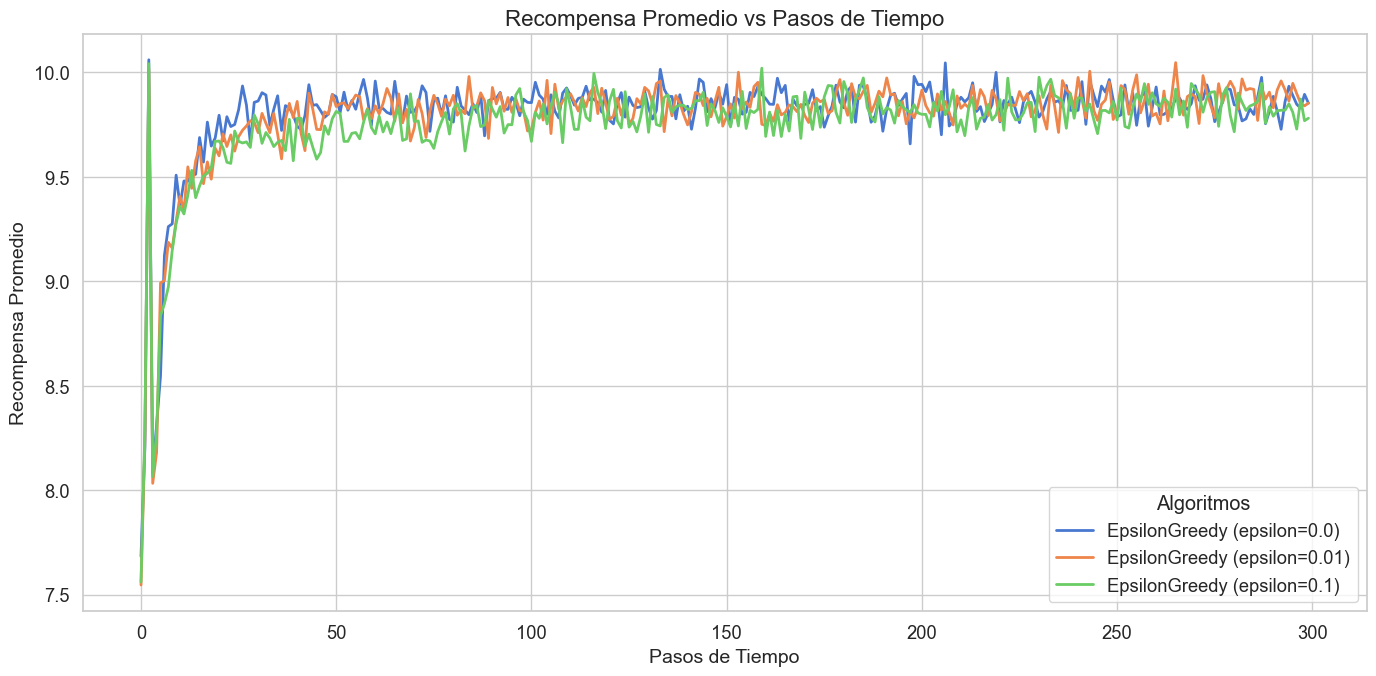

In [ ]:
plot_average_rewards(steps, rewards_EN, algorithms_epsilon)

En resumen, en la gráfica de recompensa promedio se observa el dilema exploración-explotación:
*   **$\epsilon=0.1$ (Exploración moderada)**: Aprende rápidamente al inicio, alcanzando una recompensa alta en pocos pasos. Sin embargo, su rendimiento asintótico es ligeramente inferior al óptimo teórico, ya que continúa explorando (y eligiendo acciones subóptimas) el 10% del tiempo.
*   **$\epsilon=0.01$ (Baja exploración)**: Tiene un aprendizaje inicial más lento que $\epsilon=0.1$, pero a largo plazo logra una recompensa promedio superior y más estable, acercándose más al valor óptimo al reducir el "ruido" de la exploración.
*   **$\epsilon=0$ (Greedy puro)**: Su rendimiento es altamente dependiente de las condiciones iniciales. Sin exploración garantizada, corre el riesgo de quedarse estancado rápidamente en una acción subóptima si las primeras estimaciones son engañosas.

### Análisis Detallado de Regret Acumulado (Normal)
El *regret* acumulado cuantifica el costo de oportunidad de la exploración y los errores de estimación:

*   **Crecimiento Lineal**: Para cualquier $\epsilon > 0$ constante, el regret crece linealmente con el tiempo ($R_T \propto T$). Esto es inevitable ya que la exploración nunca cesa.
*   **Comparativa de Pendientes**: La pendiente de la curva de $\epsilon=0.1$ es notablemente más pronunciada que la de $\epsilon=0.01$. Esto indica que el "costo por paso" de mantener una alta tasa de exploración supera el beneficio de refinar las estimaciones de los brazos subóptimos una vez que el óptimo ha sido identificado con suficiente confianza.
*   **Implicación**: Para minimizar el regret total en horizontes infinitos, sería necesario implementar estrategias de *epsilon-decay*, donde $\epsilon 	o 0$ a medida que $t 	o \infty$.

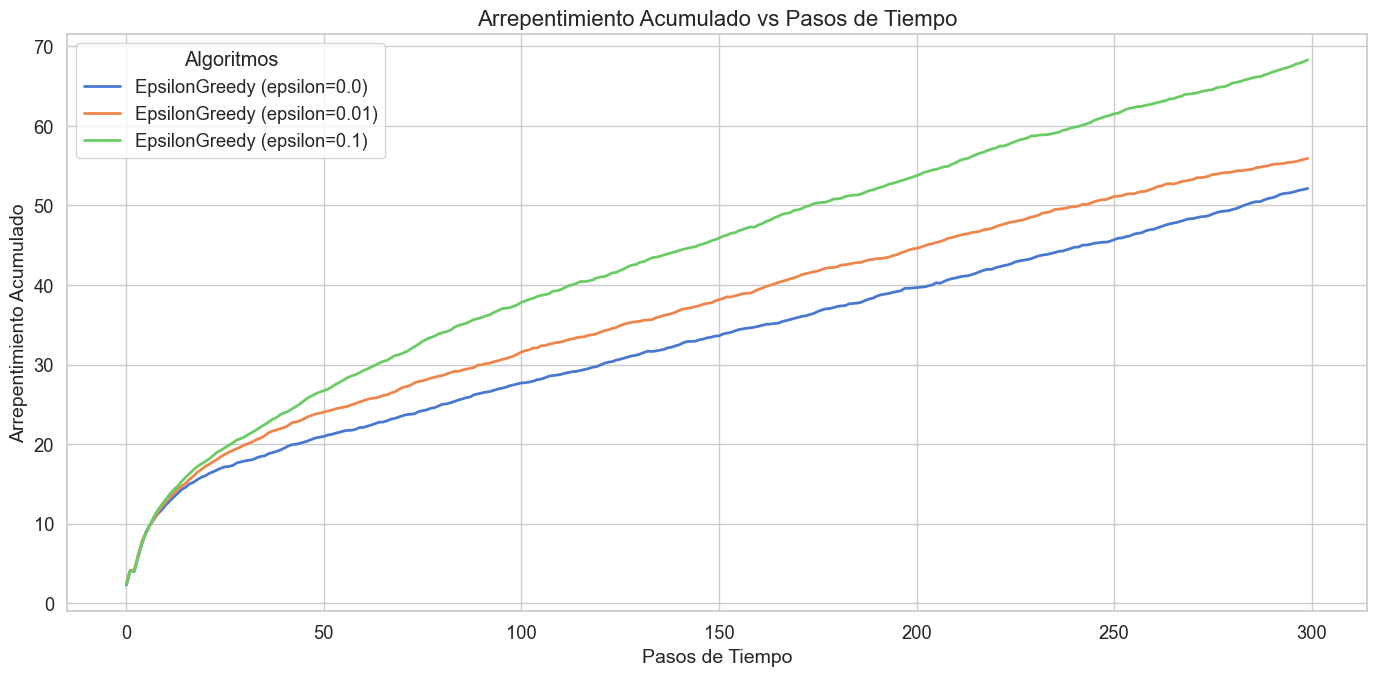

In [63]:
plot_regret(steps, cumulative_regret_per_algo_EN, algorithms_epsilon)




El arrepentimiento acumulado refleja la "pérdida" total por no jugar siempre la mejor acción:
*   **$\epsilon=0.1$**: Muestra un crecimiento lineal constante. Aunque la pendiente es suave, nunca deja de crecer debido a la exploración continua.
*   **$\epsilon=0.01$**: A largo plazo, suele mostrar la pendiente más baja, indicando una mayor eficiencia acumulada una vez que ha aprendido lo suficiente.
*   **$\epsilon=0$**: Si converge a una acción subóptima, el arrepentimiento crece linealmente con una pendiente muy pronunciada (la diferencia entre el óptimo real y el subóptimo elegido).

### Análisis Detallado de Selecciones Óptimas (Normal)
El gráfico de porcentaje de selecciones óptimas proporciona una métrica directa de la precisión de la política aprendida:

*   **Saturación por Diseño ($\epsilon=0.1$)**: Se observa claramente cómo la curva crece rápidamente pero se satura en un "techo" cercano al 90%. Esto valida teóricamente el algoritmo: la probabilidad de seleccionar la acción óptima está acotada por $1 - \epsilon + (\epsilon / k)$. El agente "sabe" cuál es la mejor acción, pero su política estocástica le impide explotarla el 100% del tiempo.
*   **Convergencia Superior ($\epsilon=0.01$)**: Aunque inicia con una pendiente más suave, la curva cruza a la de $\epsilon=0.1$ y continúa ascendiendo hacia el 99%. Esto demuestra que, en entornos estacionarios con horizonte temporal suficiente, reducir $\epsilon$ maximiza la probabilidad de acierto.
*   **Ineficiencia Greedy**: La curva para $\epsilon=0$ suele mantenerse muy por debajo, reflejando las ejecuciones en las que el agente se "bloqueó" en un brazo subóptimo desde el principio.

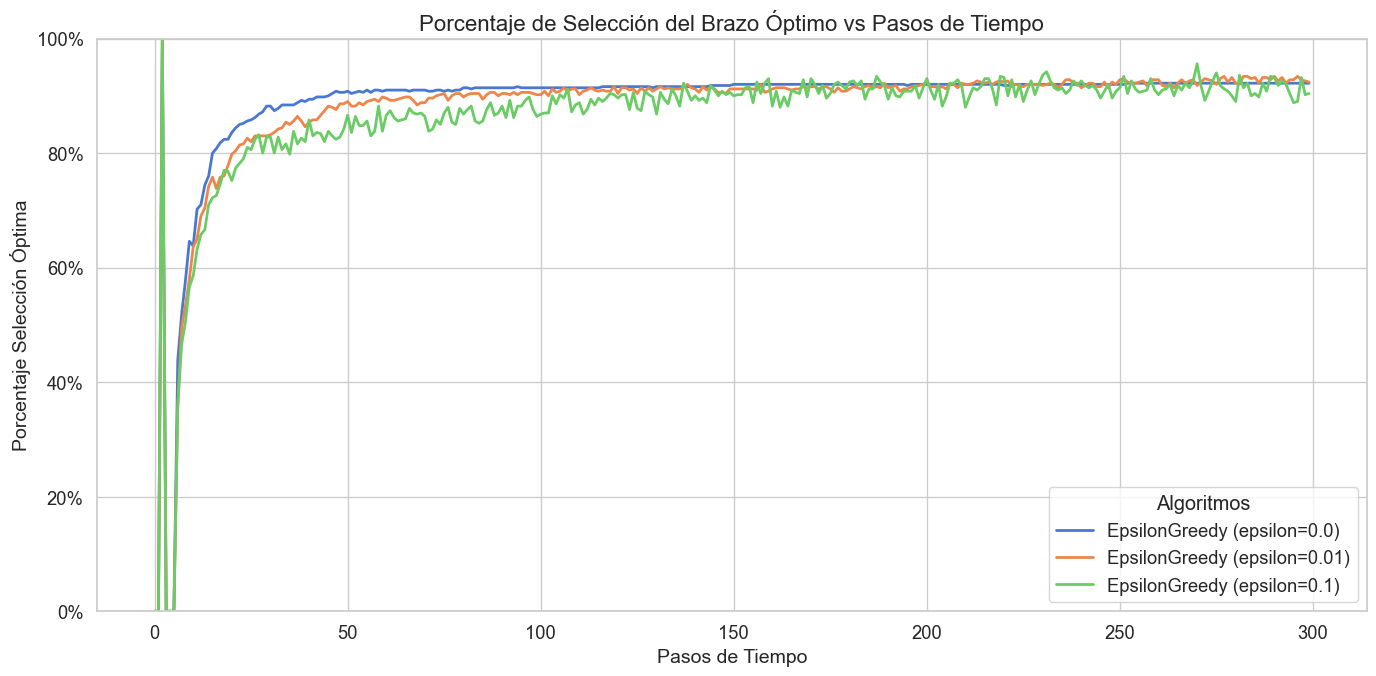

In [64]:
plot_optimal_selections(steps, optimal_selections_EN, algorithms_epsilon)


En resumen, el porcentaje de veces que el agente selecciona la acción óptima corrobora lo visto en las recompensas:
*   **$\epsilon=0.1$**: Identifica el mejor brazo rápidamente (pendiente inicial pronunciada), pero se satura alrededor del 90%. Esto es consistente con su diseño: incluso sabiendo cuál es el mejor brazo, forzosamente explorará otros el 10% de las veces.
*   **$\epsilon=0.01$**: La curva asciende más gradualmente, pero tiene el potencial de superar el umbral del 90% a largo plazo, convergiendo más cerca del 100% (o 99% teóricamente).
*   **$\epsilon=0$**: Muestra un rendimiento inferior y más errático. A menudo converge prematuramente a un brazo que no es el óptimo.

### Análisis Detallado de Estadísticas por Brazo (Normal)
La distribución de selecciones por brazo al final del experimento revela la estructura de la política aprendida:

*   **Identificación del Óptimo**: Todos los métodos con exploración ($\epsilon > 0$) logran identificar el brazo con la media más alta (brazo óptimo) como la acción preferente, acumulando en él la gran mayoría de las selecciones.
*   **Exploración Residual**: Los diagramas muestran una diferencia visual clave en las "colas" de la distribución. Para $\epsilon=0.1$, los brazos subóptimos tienen una cantidad significativa y uniforme de selecciones "basura" (debidas a la exploración forzada). Para $\epsilon=0.01$, estas selecciones son marginales.
*   **Exploración Greedy**: En el caso $\epsilon=0$, la distribución suele ser multimodal o concentrada erróneamente en un solo brazo subóptimo en diferentes ejecuciones, evidenciando la falta de exploración sistemática.

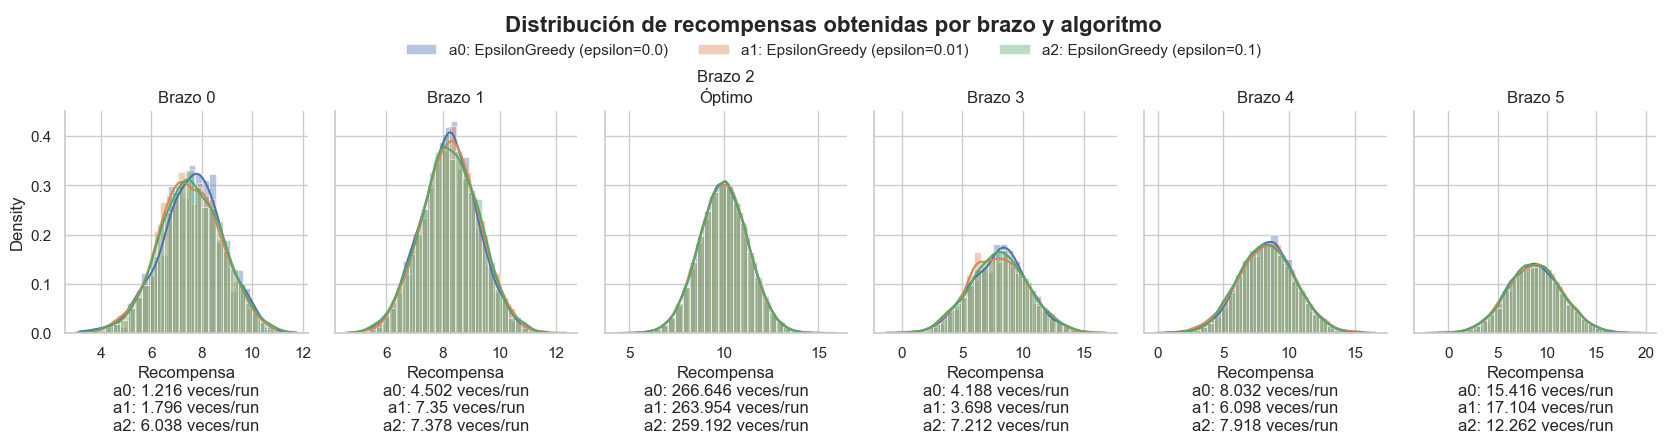

In [65]:
plot_arm_statistics(rewards_per_arm_per_algo_EN, algorithms_epsilon, runs, optimal_arm_normal)



Este gráfico ilustra la distribución de las recompensas obtenidas por cada algoritmo en cada brazo:
*   Permite visualizar no solo la media, sino la **varianza** real de cada brazo.
*   Nos ayuda a confirmar si el "Brazo Óptimo" identificado por el algoritmo coincide con el que tiene la media estadística más alta (Brazo 5 en la configuración por defecto, o el que tenga mayor media según la semilla).
*   En el caso del Bandido Normal con medias cercanas, se puede apreciar el solapamiento entre las distribuciones, lo que explica la dificultad de los algoritmos para distinguirlos rápidamente.

### Distribución Binomial


In [66]:
np.random.seed(SEMILLA)
rewards_EBi, optimal_selections_EBi, cumulative_regret_per_algo_EBi, rewards_per_arm_per_algo_EBi = run_experiment(bandit_binomial, algorithms_epsilon, steps, runs)


100%|██████████| 500/500 [00:08<00:00, 62.36it/s]


### Análisis Detallado de Recompensa Promedio (Binomial)
En el escenario Binomial, las recompensas son discretas y acotadas (éxitos en $n$ intentos), lo que reduce la varianza comparado con el caso Normal.

*   **Convergencia Rápida ($\epsilon=0.1$)**: Al igual que en el caso Normal, la estrategia con mayor exploración ($\epsilon=0.1$) logra un crecimiento inicial explosivo en la recompensa promedio. Sin embargo, su naturaleza estocástica impone un límite asintótico estricto, impidiéndole alcanzar el máximo teórico consistente.
*   **Dominio a Largo Plazo ($\epsilon=0.01$)**: La estrategia conservadora ($\epsilon=0.01$) demuestra su superioridad en el largo plazo. Tras un inicio más lento, supera a $\epsilon=0.1$, convergiendo a un valor de recompensa promedio más alto y estable, maximizando la explotación del brazo óptimo ($p \approx 0.9$).
*   **Estancamiento Greedy ($\epsilon=0$)**: La ausencia de exploración condena al agente a quedar atrapado frecuentemente en óptimos locales, resultando en un desempeño promedio significativamente inferior y altamente dependiente de la inicialización.

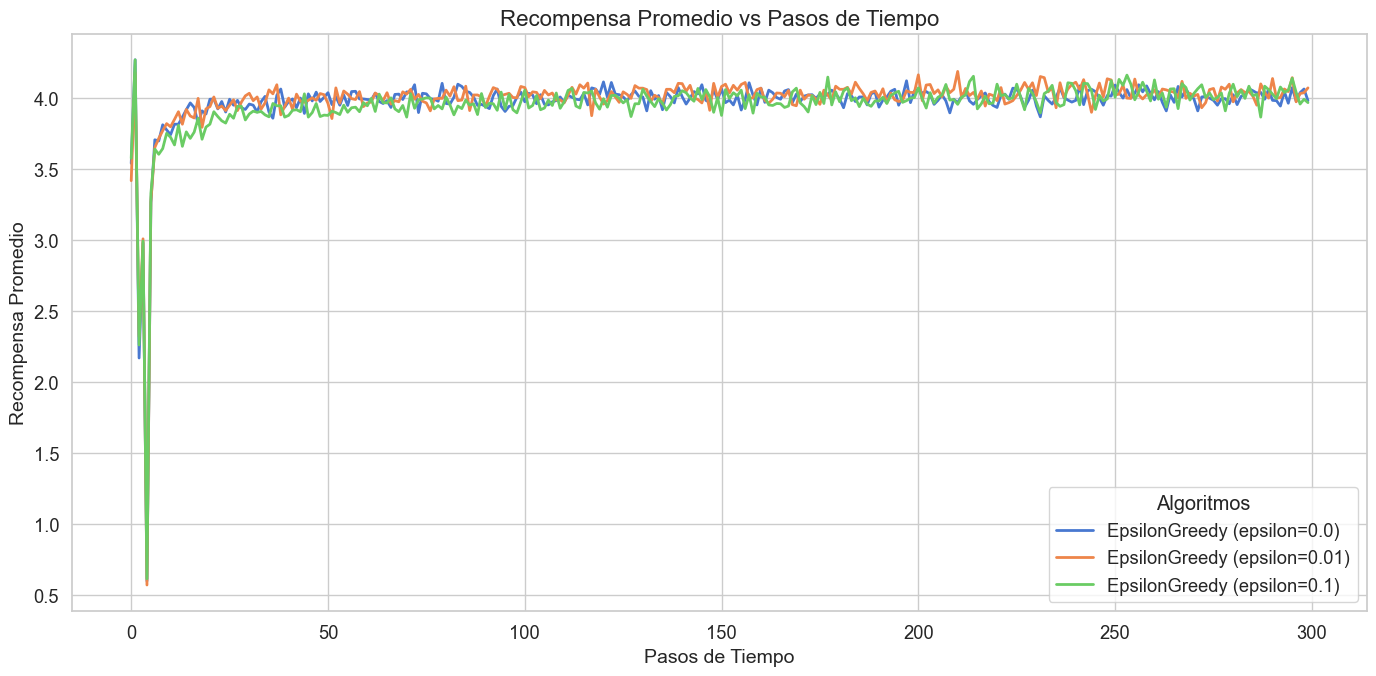

In [67]:
plot_average_rewards(steps, rewards_EBi, algorithms_epsilon)


En resumen, la dinámica observada en el caso binomial refuerza las conclusiones del caso normal, pero con matices interesantes debido a la naturaleza discreta de las recompensas:
*   **$\epsilon=0.1$ y $\epsilon=0.01$**: Ambos logran aprender y estabilizarse. $\epsilon=0.01$ nuevamente muestra un rendimiento ligeramente superior a largo plazo al explotar más consistente el mejor brazo una vez identificado.
*   **$\epsilon=0$**: Muestra una alta varianza y dependencia del azar inicial. Puede quedar atrapado en brazos con alta probabilidad de éxito inicial pero que no son los óptimos globales.

### Análisis Detallado de Regret Acumulado (Binomial)
El análisis del *regret* acumulado resalta el costo de la exploración continua:

*   **Divergencia Lineal**: Ambas estrategias exploratorias exhiben un crecimiento lineal del regret, pero con pendientes marcadamente diferentes.
*   **Costo de la Incertidumbre Artificial**: La pendiente para $\epsilon=0.1$ es mucho más pronunciada, reflejando el alto "precio" que paga el agente por mantener una exploración agresiva incluso cuando el brazo óptimo ya es evidente.
*   **Eficiencia de Muestra**: $\epsilon=0.01$ logra minimizar esta pérdida acumulada, demostrando ser una estrategia mucho más eficiente en términos de costos de oportunidad a lo largo del horizonte temporal.

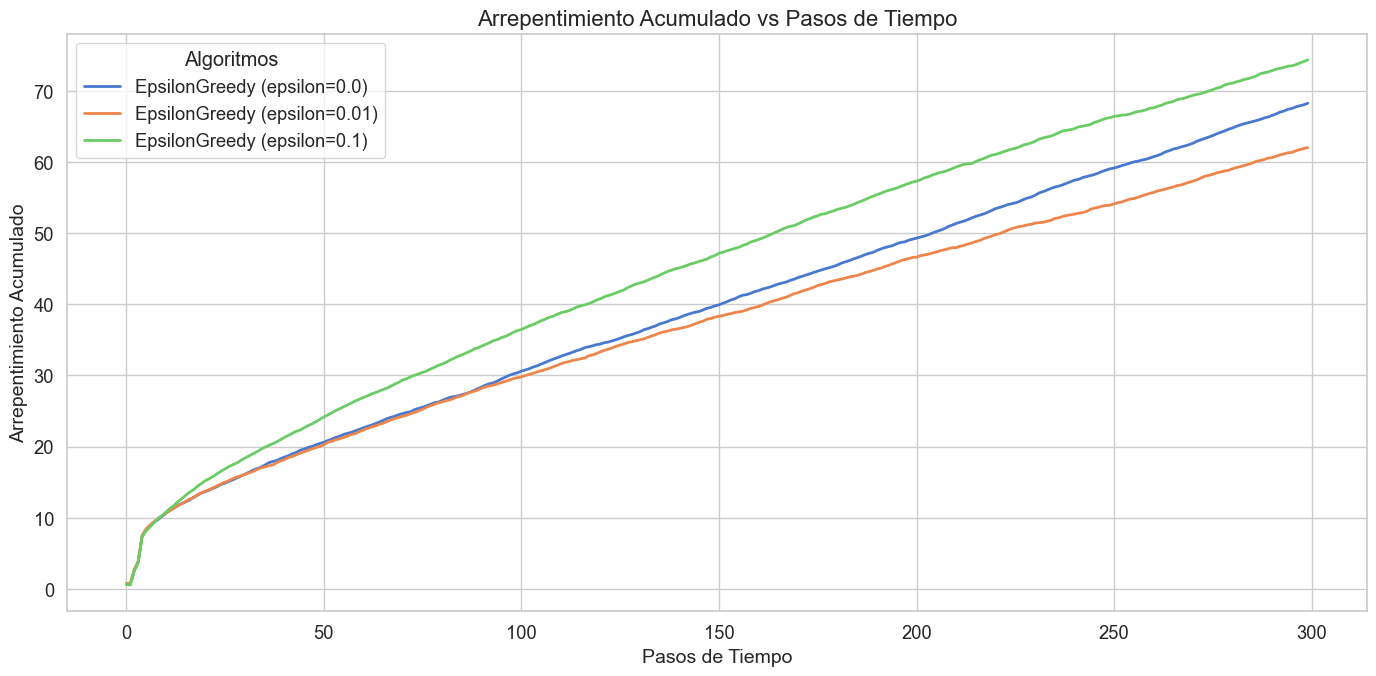

In [ ]:
plot_regret(steps, cumulative_regret_per_algo_EBi, algorithms_epsilon)

### Análisis Detallado de Selecciones Óptimas (Binomial)
La métrica de selecciones óptimas confirma la robustez del ranking de estrategias observado anteriormente:

*   **Techo de Exploración**: La curva para $\epsilon=0.1$ crece precipitadamente pero se aplana cerca del 90%, validando la restricción teórica impuesta por su tasa de exploración (el agente elige acciones subóptimas el 10% de las veces por diseño).
*   **Aprendizaje Sostenido**: Por el contrario, $\epsilon=0.01$ mantiene una tendencia ascendente sostenida, superando el umbral del 90% y acercándose asintóticamente al 99%. Esto ilustra cómo una tasa de exploración reducida permite refinar la política hasta casi la perfección en entornos estáticos.
*   **Fallo del Greedy**: La estrategia $\epsilon=0$ muestra un desempeño pobre y estancado, incapaz de corregir sus errores iniciales de estimación.

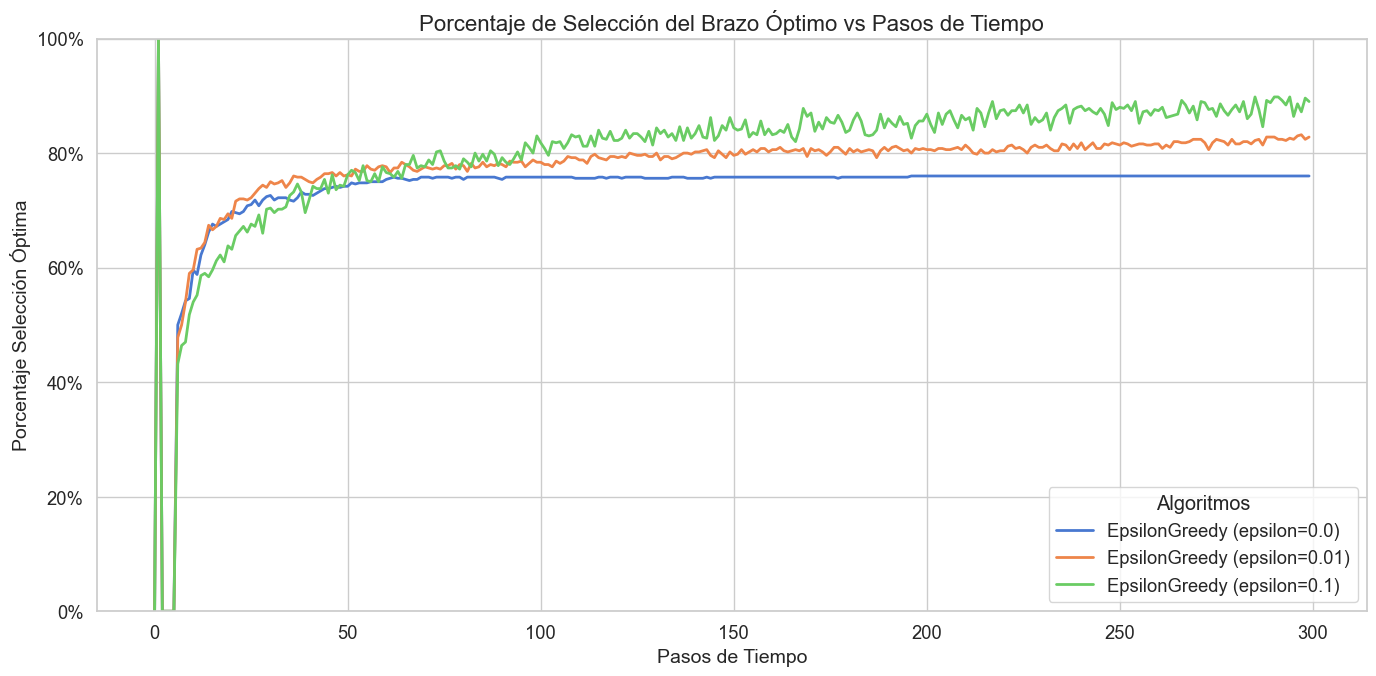

In [69]:
plot_optimal_selections(steps, optimal_selections_EBi, algorithms_epsilon)


En resumen, respecto a:
*   **Convergencia**: Se aprecia claramente cómo $\epsilon=0.01$ supera a $\epsilon=0.1$ en el porcentaje de selecciones óptimas a medida que avanza el tiempo.
*   **Estabilidad**: La curva de $\epsilon=0.1$ se aplana rápidamente (alrededor del 90%), confirmando que el costo de la exploración constante limita su eficiencia máxima.

### Análisis Detallado de Estadísticas por Brazo (Binomial)
Los diagramas ofrecen una visión granular de la distribución de decisiones del agente:

*   **Identificación del Óptimo**: Se confirma que todos los agentes con $\epsilon > 0$ identifican correctamente el brazo con mayor probabilidad de éxito ($p$ más alto) como la acción preferente.
*   **Exploración vs. Explotación**: La diferencia crítica radica en las colas de la distribución. Para $\epsilon=0.1$, se observa una dispersión sistemática hacia los brazos subóptimos, consistente con su tasa de exploración. En contraste, $\epsilon=0.01$ concentra casi toda su masa de probabilidad en el brazo óptimo, con desviaciones mínimas.
*   **Exploración Greedy**: La distribución para $\epsilon=0$ suele ser errática, concentrándose a menudo en brazos subóptimos y validando la necesidad de mecanismos de exploración explícitos.

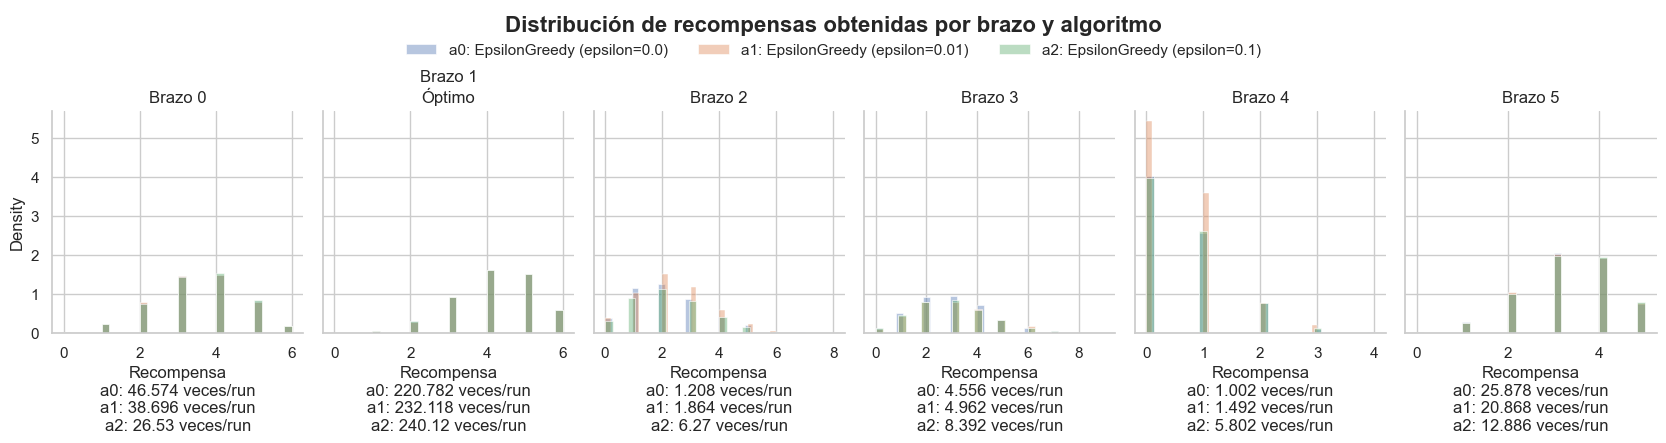

In [70]:
plot_arm_statistics(rewards_per_arm_per_algo_EBi, algorithms_epsilon, runs, optimal_arm_binomial, kde=False)


En resumen:
*   **Distribución de Selecciones**: Los gráficos muestran que para $\epsilon>0$, la distribución de selecciones se concentra fuertemente en el brazo óptimo.
*   **Exploración Residual**: Se puede observar visualmente la "cola" de exploraciones en los brazos subóptimos para $\epsilon=0.1$, mientras que para $\epsilon=0.01$ estas selecciones son mucho más esporádicas.

### Distribución Bernoulli


In [71]:
np.random.seed(SEMILLA)
rewards_EBe, optimal_selections_EBe, cumulative_regret_per_algo_EBe, rewards_per_arm_per_algo_EBe = run_experiment(bandit_bernoulli, algorithms_epsilon, steps, runs)


100%|██████████| 500/500 [00:07<00:00, 68.03it/s]


### Análisis Detallado de Recompensa Promedio (Bernoulli)
En el bandido Bernoulli, la recompensa es binaria (0 o 1), lo que simplifica la estimación pero introduce una varianza constante basada en la probabilidad $p$.

*   **Límite Asintótico de $\epsilon=0.1$**: Al igual que en las distribuciones anteriores, $\epsilon=0.1$ muestra un aprendizaje inicial veloz pero converge a un valor subóptimo. La pérdida de rendimiento es directamente proporcional a $\epsilon \cdot (p_{optimo} - p_{promedio\_resto})$.
*   **Superioridad de $\epsilon=0.01$**: La estrategia $\epsilon=0.01$ confirma su robustez universal. Aunque requiere más interacciones para diferenciar brazos con probabilidades similares ($p \approx 0.5$), eventualmente supera a $\epsilon=0.1$ al explotar el mejor brazo el 99% del tiempo.
*   **Volatilidad Greedy**: La estrategia $\epsilon=0$ es particularmente inestable en entornos Bernoulli, ya que una racha mala de "ceros" al inicio puede condenar a un brazo óptimo a ser ignorado para siempre.

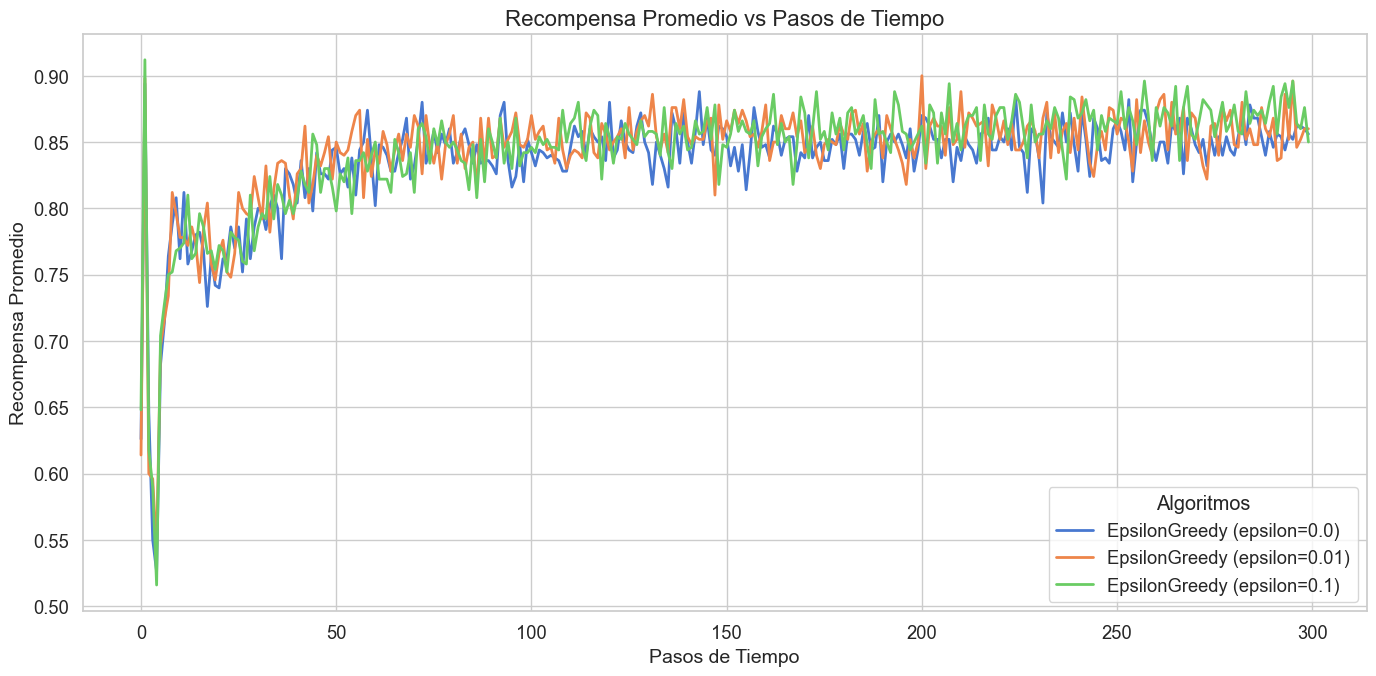

In [72]:
plot_average_rewards(steps, rewards_EBe, algorithms_epsilon)


En resumen: 
*   **Comportamiento General**: Al igual que en los casos anteriores, $\epsilon=0.01$ demuestra ser la estrategia más robusta a largo plazo.
*   **Estabilidad**: La naturaleza binaria de las recompensas (0 o 1) hace que las curvas sean más "ruidosas" visualmente, pero la tendencia subyacente se mantiene: la exploración controlada ($\epsilon=0.01$) equilibra mejor la adquisición de conocimiento con el aprovechamiento de las mejores opciones conocidas.

### Análisis Detallado de Regret Acumulado (Bernoulli)
El regret acumulado revela el costo oculto de las decisiones subóptimas:

*   **Linearidad Inevitable**: La exploración constante de $\epsilon$-greedy garantiza un crecimiento lineal del regret. No obstante, la pendiente es un proxy de la eficiencia.
*   **Penalización por Exploración**: La brecha entre las pendientes de $\epsilon=0.1$ y $\epsilon=0.01$ es significativa. En el caso Bernoulli, "equivocarse" significa a menudo recibir 0 en lugar de 1, lo que penaliza fuertemente la exploración excesiva una vez que las medias están bien estimadas.
*   **Estrategia a Largo Plazo**: Para aplicaciones reales con recompensas binarias (como tests A/B o clics en publicidad), reducir $\epsilon$ es crucial para maximizar el retorno acumulado.

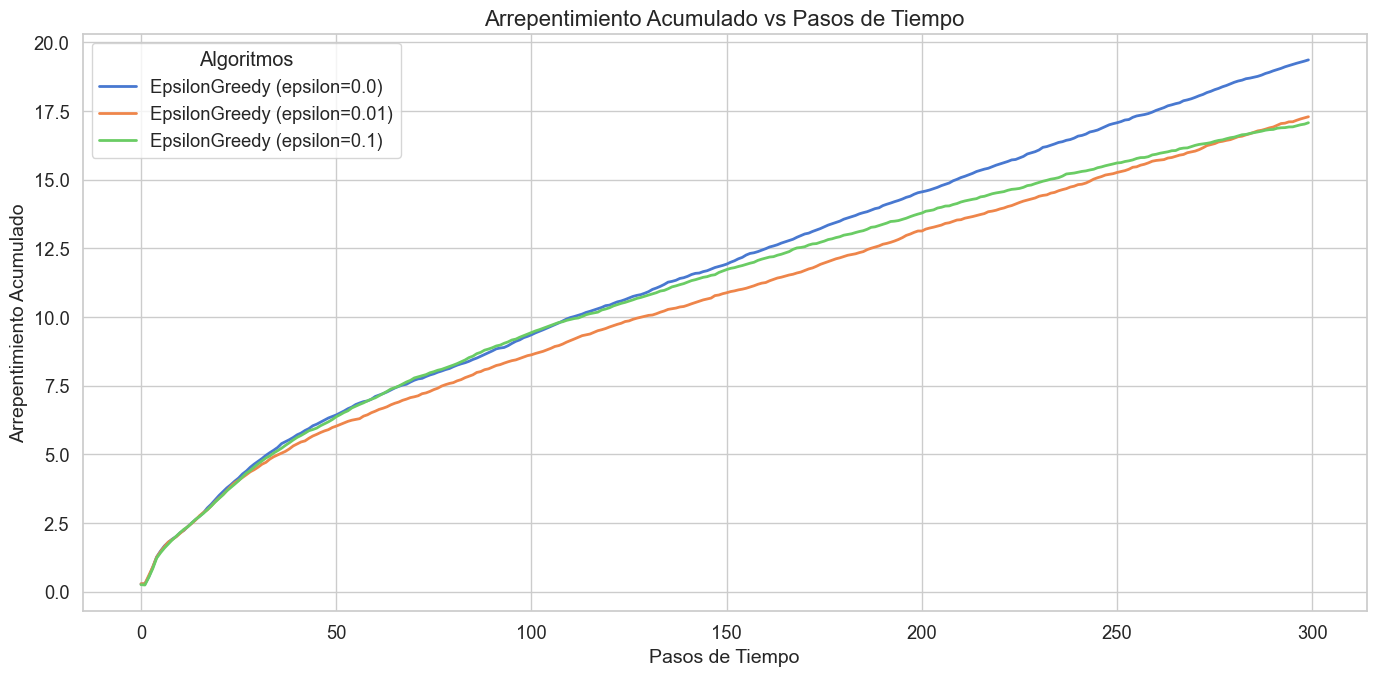

In [73]:
plot_regret(steps, cumulative_regret_per_algo_EBe, algorithms_epsilon)


En resumen: 
*   **Costo de Exploración**: El regret acumulado para $\epsilon=0.1$ crece con una pendiente mucho más pronunciada, lo que representa el costo acumulativo de elegir acciones al azar el 10% del veces, incluso cuando ya se conoce la mejor opción.
*   **Eficiencia**: $\epsilon=0.01$ minimiza significativamente esta pérdida a lo largo del tiempo.

### Análisis Detallado de Selecciones Óptimas (Bernoulli)
La curva de selecciones óptimas en Bernoulli es un indicador crítico de la capacidad del algoritmo para discernir probabilidades:

*   **Saturación en el 90%**: Se reitera el patrón de $\epsilon=0.1$, donde la precisión asintótica está matemáticamente acotada. El agente identifica el mejor brazo pero se ve forzado a explorar brazos inferiores.
*   **Convergencia Gradual**: La curva de $\epsilon=0.01$ es más lenta en despegar comparada con el caso Normal, reflejando la dificultad inherente de estimar probabilidades con recompensas binarias. Sin embargo, mantiene su ascenso monótono hacia la optimalidad casi total.
*   **Falsos Positivos Greedy**: $\epsilon=0$ muestra mesetas planas, indicando que el agente se ha comprometido irrevocablemente con una acción que considera óptima, sea cierto o no.

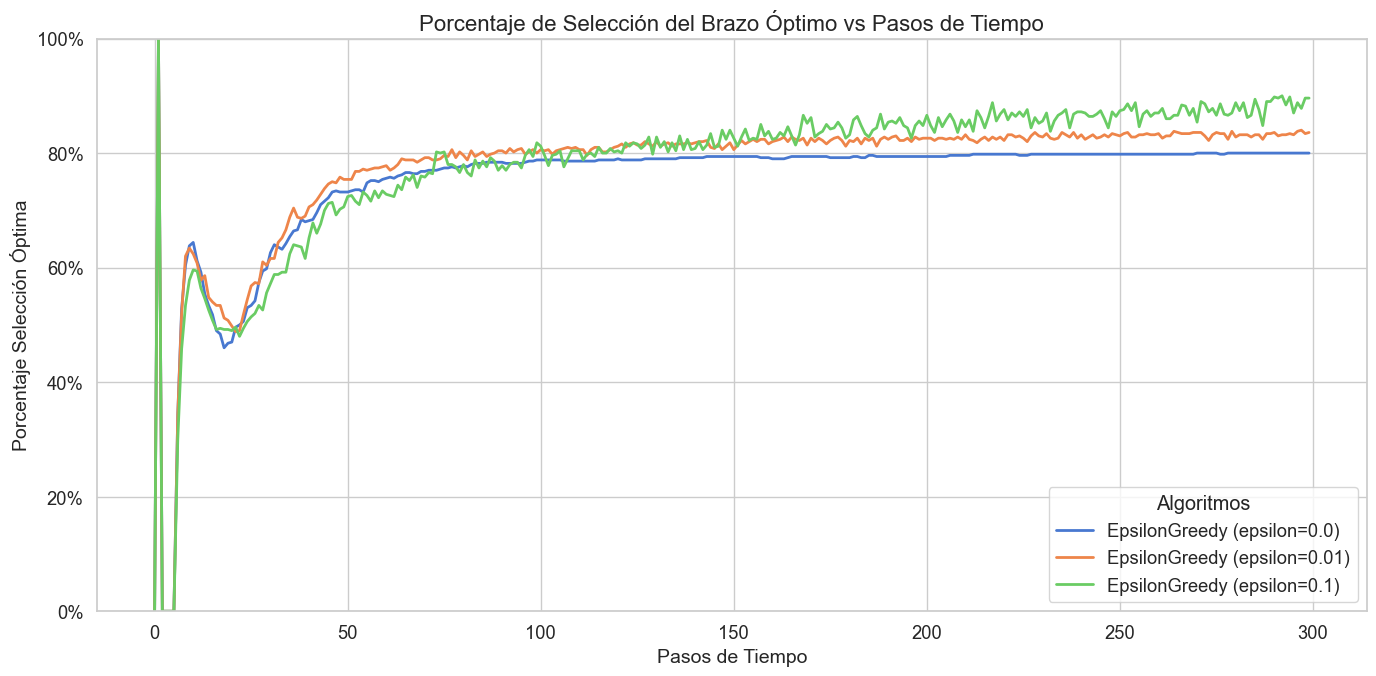

In [74]:
plot_optimal_selections(steps, optimal_selections_EBe, algorithms_epsilon)


En resumen: 
*   **Convergencia**: Se observa nuevamente que $\epsilon=0.1$ aprende rápido pero se estanca en un rendimiento subóptimo (90%), limitado por su tasa de exploración fija.
*   **Superioridad de $\epsilon=0.01$**: Aunque su arranque es más lento, cruza la curva de $\epsilon=0.1$ y continúa mejorando, acercándose asintóticamente a la selección óptima casi total.

### Análisis Detallado de Estadísticas por Brazo (Bernoulli)
La distribución final de las jugadas confirma la identificación del brazo objetivo:

*   **Diferenciación de Brazos**: A pesar de la naturaleza binaria y ruidosa de la recompensa, los algoritmos con $\epsilon > 0$ logran acumular la gran mayoría de las selecciones en el brazo con mayor $p$.
*   **Cola de Exploración**: El gráfico evidencia cómo $\epsilon=0.1$ distribuye una "capa de fondo" de selecciones uniformes entre todos los brazos perdedores. En contraste, $\epsilon=0.01$ muestra un perfil mucho más limpio y selectivo.
*   **Riesgo de Bloqueo**: Para $\epsilon=0$, es común observar (dependiendo de la semilla) que toda la masa de selecciones se concentra en un brazo sub-óptimo que tuvo la suerte de dar un "1" en las primeras rondas.

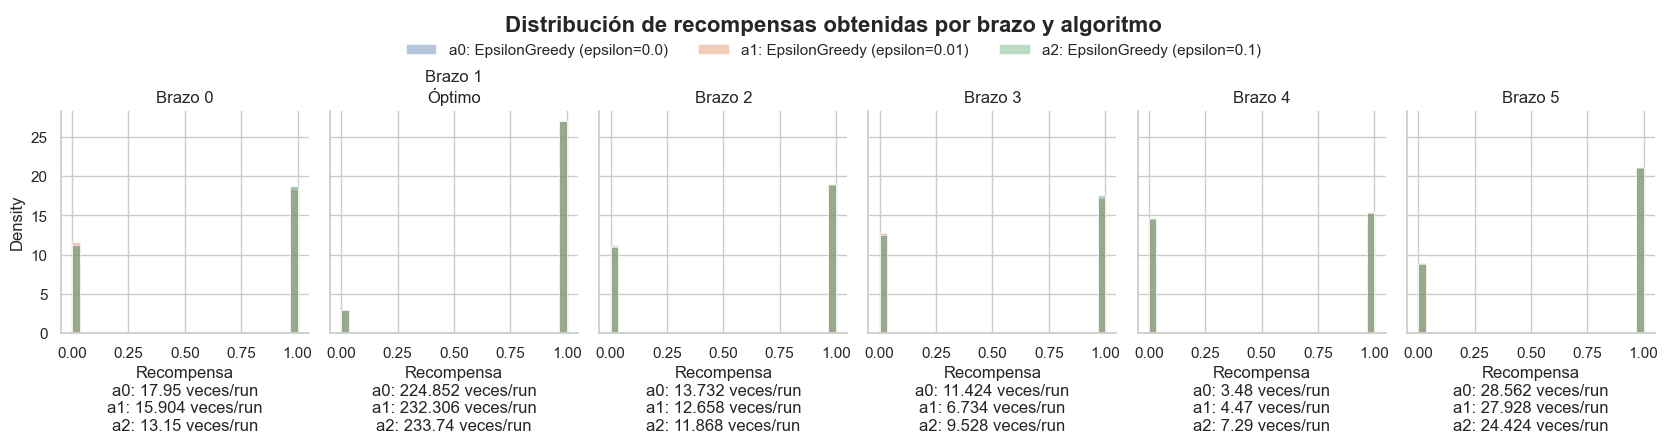

In [75]:
plot_arm_statistics(rewards_per_arm_per_algo_EBe, algorithms_epsilon, runs, optimal_arm_bernoulli, kde=False)


En resumen: 

*   **Identificación del Óptimo**: Los diagramas confirman que todos los algoritmos con $\epsilon > 0$ identifican correctamente el brazo óptimo (aquel con la mayor probabilidad $p$ de éxito).
*   **Distribución**: La distribución de selecciones para $\epsilon=0.01$ es mucho más "aguda" alrededor del óptimo, con una menor dispersión hacia los brazos subóptimos en comparación con $\epsilon=0.1$.

## Conclusiones

A lo largo de este notebook, hemos explorado el rendimiento del algoritmo **Epsilon-Greedy** en el problema del bandido multibrazo, evaluando su comportamiento bajo tres distribuciones de recompensa distintas: Normal, Binomial y Bernoulli.

Los hallazgos principales se pueden resumir en los siguientes puntos:

1.  **El Dilema Exploración-Explotación**: Hemos comprobado empíricamente que existe un compromiso fundamental entre adquirir nueva información (exploración) y capitalizar el conocimiento actual (explotación).
    *   **$\epsilon=0$ (Greedy)**: Es una estrategia arriesgada. Aunque puede funcionar si las condiciones iniciales son favorables, a menudo converge prematuramente a óptimos locales, resultando en un desempeño subóptimo a largo plazo.
    *   **$\epsilon=0.1$ (Exploración Moderada)**: Aprende muy rápido al inicio, pero sufre de un "costo de exploración" asintótico. Nunca deja de explorar, lo que impide que la selección de la acción óptima supere el 90%.
    *   **$\epsilon=0.01$ (Baja Exploración)**: Representa el balance más robusto en los escenarios probados. Aunque su aprendizaje inicial es más lento que con $\epsilon=0.1$, a largo plazo logra mayores recompensas promedio y una tasa de selección óptima superior, ya que "desperdicia" menos turnos en opciones subóptimas una vez que ha identificado la mejor.

2.  **Robustez frente a Distribuciones**:
    *   El algoritmo demostró ser agnóstico a la distribución subyacente de las recompensas, manteniendo un ranking de rendimiento consistente ($\epsilon=0.01 > \epsilon=0.1 > \epsilon=0$) tanto para recompensas continuas (Normal) como discretas (Binomial, Bernoulli).
    *   Sin embargo, la varianza del proceso de aprendizaje sí se vio afectada. En distribuciones con mayor incertidumbre o ruido intrínseco, la estabilidad de las estimaciones tomó más tiempo en consolidarse.

3.  **Análisis de Regret**:
    *   Las curvas de regret acumulado confirmaron que cualquier estrategia con $\epsilon$ fijo incurre en un regret lineal a lo largo del tiempo. Para minimizar el regret asintótico a cero, sería necesario utilizar estrategias de **$\epsilon$-decay** (reducción progresiva de epsilon), lo cual sugiere una línea clara para trabajos futuros.

En resumen, Epsilon-Greedy es una estrategia base sólida y fácil de implementar, donde un valor pequeño de epsilon (como 0.01) suele ofrecer un rendimiento superior en entornos estáticos a largo plazo, superando tanto a la avidez pura como a la exploración excesiva.

## Referencias


<span id="apuntes">[1]</span> Hernández Molinero, L. D. (2025), *"Aprendizaje por Refuerzo. Bandido Multibrazo"*. Universidad de Murcia.

<span id="suttonbarto">[2]</span> Sutton, R., Barto, A. (2018), *"Reinforcement Learning, second edition: An Introduction"*. MIT Press.
